<a href="https://colab.research.google.com/github/daaastis/fundamentals-of-data-mining/blob/main/%D0%BF%D0%BE%D0%B8%D1%81%D0%BA%D1%87%D0%B0%D1%81%D1%82%D1%8B%D1%85%D0%BD%D0%B0%D0%B1%D0%BE%D1%80%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ЭТАП 1: ПОДГОТОВКА И ЧТЕНИЕ НАБОРА ДАННЫХ 
[+] Файл успешно прочитан с кодировкой: cp1251
[Успешно] Загружено транзакций: 7501

 РЕЗУЛЬТАТЫ ПОИСКА ЧАСТЫХ НАБОРОВ ОБЪЕКТОВ (min_support = 3%)
Набор объектов                                | Поддержка  | Длина
-----------------------------------------------------------------
минеральная вода                              | 0.2384     | 1
макароны                                      | 0.1880     | 1
яйца                                          | 0.1797     | 1
картофель-фри                                 | 0.1709     | 1
шоколад                                       | 0.1638     | 1
зеленый чай                                   | 0.1321     | 1
молоко                                        | 0.1296     | 1
говяжий фарш                                  | 0.0983     | 1
замороженные овощи                            | 0.0953     | 1
блинчики                                      | 0.0951     | 1
гамбургер                                     

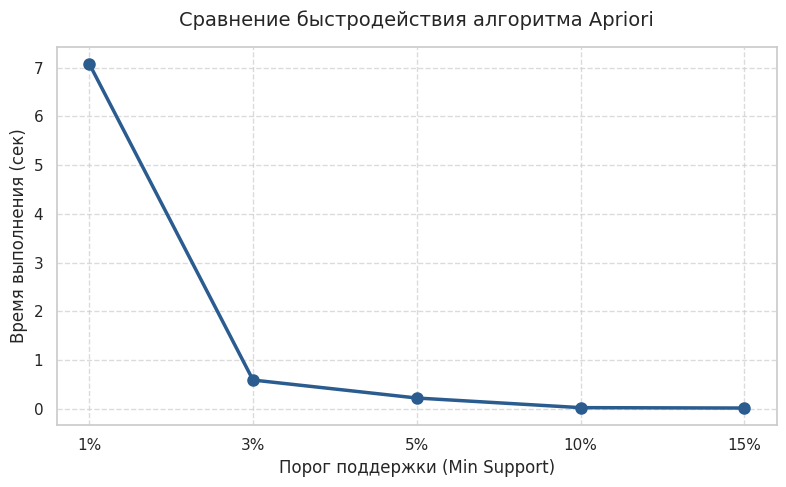

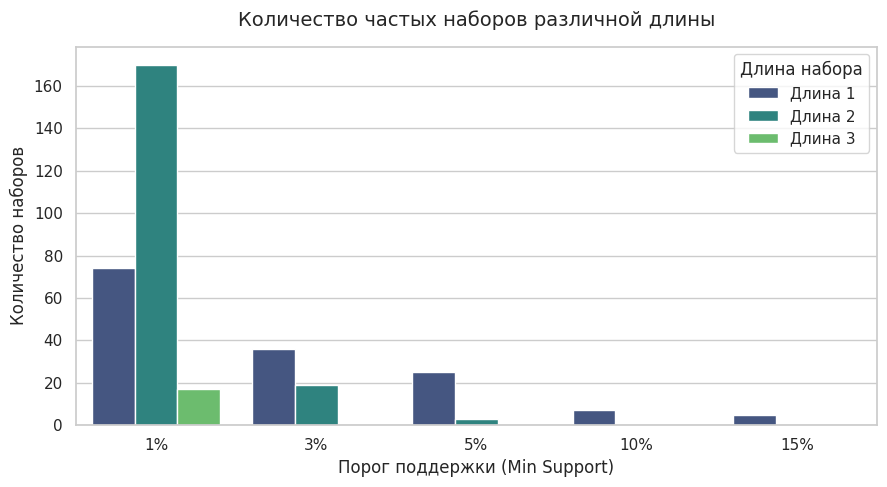

In [ ]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# -----------------------------------------------------------------
print("=" * 65)
print(" ЭТАП 1: ПОДГОТОВКА И ЧТЕНИЕ НАБОРА ДАННЫХ ")
print("=" * 65)

dataset_filename = 'baskets.csv'

def load_baskets_dataset(filename):
    encodings = ['cp1251', 'utf-8', 'windows-1251', 'latin1']
    for enc in encodings:
        try:
            df = pd.read_csv(filename, header=None, encoding=enc)
            print(f"[+] Файл успешно прочитан с кодировкой: {enc}")
            return df
        except Exception:
            continue
    return None

df_raw = load_baskets_dataset(dataset_filename)

if df_raw is None:
    raise FileNotFoundError("Не удалось прочитать файл baskets.csv. Загрузите его в файлы Colab.")

# Формирование списка транзакций
transactions = []
for _, row in df_raw.iterrows():
    basket = list(row.dropna().astype(str).str.strip())
    if basket:
        transactions.append(basket)

print(f"[Успешно] Загружено транзакций: {len(transactions)}")


# -----------------------------------------------------------------
# 2. РЕАЛИЗАЦИЯ АЛГОРИТМА APRIORI
# -----------------------------------------------------------------
class Apriori:
    def __init__(self, min_support=0.05, sort_by='support_desc'):
        """
        :param min_support: Порог поддержки (от 0.0 до 1.0)
        :param sort_by: 'support_desc', 'support_asc', 'lexicographical'
        """
        self.min_support = min_support
        self.sort_by = sort_by

    def fit(self, transactions):
        num_transactions = len(transactions)
        min_count = self.min_support * num_transactions

        # 1-элементные наборы
        item_counts = {}
        for transaction in transactions:
            for item in set(transaction):
                item_counts[item] = item_counts.get(item, 0) + 1

        current_l = {frozenset([item]): count for item, count in item_counts.items() if count >= min_count}
        frequent_itemsets = dict(current_l)

        # Генерация k-элементных кандидатов
        k = 2
        while current_l:
            items = list(current_l.keys())
            candidates = set()
            for i in range(len(items)):
                for j in range(i + 1, len(items)):
                    union_set = items[i] | items[j]
                    if len(union_set) == k:
                        subsets = [union_set - frozenset([elem]) for elem in union_set]
                        if all(sub in current_l for sub in subsets):
                            candidates.add(union_set)

            # Подсчет поддержки кандидатов
            candidate_counts = {cand: 0 for cand in candidates}
            for transaction in transactions:
                trans_set = set(transaction)
                for cand in candidates:
                    if cand.issubset(trans_set):
                        candidate_counts[cand] += 1

            current_l = {cand: count for cand, count in candidate_counts.items() if count >= min_count}
            frequent_itemsets.update(current_l)
            k += 1

        # Формирование результатов
        results = []
        for itemset, count in frequent_itemsets.items():
            results.append({
                'itemset': sorted(list(itemset)),
                'support': count / num_transactions,
                'length': len(itemset)
            })

        # Упорядочивание результатов
        if self.sort_by == 'support_desc':
            results.sort(key=lambda x: x['support'], reverse=True)
        elif self.sort_by == 'support_asc':
            results.sort(key=lambda x: x['support'])
        elif self.sort_by == 'lexicographical':
            results.sort(key=lambda x: str(x['itemset']))

        return results


# -----------------------------------------------------------------
# 3. ДЕМОНСТРАЦИОННЫЙ ВЫВОД РЕЗУЛЬТАТОВ
# -----------------------------------------------------------------
print("\n" + "=" * 65)
print(" РЕЗУЛЬТАТЫ ПОИСКА ЧАСТЫХ НАБОРОВ ОБЪЕКТОВ (min_support = 3%)")
print("=" * 65)

demo_apriori = Apriori(min_support=0.03, sort_by='support_desc')
demo_results = demo_apriori.fit(transactions)

print(f"{'Набор объектов':<45} | {'Поддержка':<10} | {'Длина'}")
print("-" * 65)
for res in demo_results[:20]:
    items_str = ", ".join(res['itemset'])
    print(f"{items_str:<45} | {res['support']:<10.4f} | {res['length']}")
print("-" * 65)
print(f"Всего найдено частых наборов (при min_support=3%): {len(demo_results)}")


# -----------------------------------------------------------------
# 4. ЭКСПЕРИМЕНТЫ И ВИЗУАЛИЗАЦИЯ
# -----------------------------------------------------------------
print("\n" + "=" * 65)
print(" ПРОВЕДЕНИЕ ЭКСПЕРИМЕНТОВ И ПОСТРОЕНИЕ ДИАГРАММ ")
print("=" * 65)

thresholds = [0.01, 0.03, 0.05, 0.10, 0.15]
exec_times = []
results_by_threshold = {}

for thresh in thresholds:
    start_t = time.time()
    model = Apriori(min_support=thresh, sort_by='support_desc')
    res = model.fit(transactions)
    elapsed = time.time() - start_t

    exec_times.append(elapsed)
    results_by_threshold[thresh] = res
    print(f"[+] Порог: {int(thresh*100):2d}% | Частых наборов: {len(res):4d} | Время: {elapsed:.3f} сек.")

# Настройка визуального стиля
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# График 1: Быстродействие
plt.figure(figsize=(8, 5))
plt.plot([f"{int(t*100)}%" for t in thresholds], exec_times, marker='o', color='#2b5c8f', linewidth=2.5, markersize=8)
plt.title("Сравнение быстродействия алгоритма Apriori", fontsize=14, pad=15)
plt.xlabel("Порог поддержки (Min Support)", fontsize=12)
plt.ylabel("Время выполнения (сек)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# График 2: Распределение по длинам
lengths_data = []
for thresh in thresholds:
    res = results_by_threshold[thresh]
    counts = {}
    for r in res:
        l = r['length']
        counts[l] = counts.get(l, 0) + 1
    for l, cnt in counts.items():
        lengths_data.append({'Threshold': f"{int(thresh*100)}%", 'Length': f"Длина {l}", 'Count': cnt})

df_lengths = pd.DataFrame(lengths_data)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_lengths, x='Threshold', y='Count', hue='Length', palette='viridis')
plt.title("Количество частых наборов различной длины", fontsize=14, pad=15)
plt.xlabel("Порог поддержки (Min Support)", fontsize=12)
plt.ylabel("Количество наборов", fontsize=12)
plt.legend(title="Длина набора")
plt.tight_layout()
plt.show()